In [1]:
# Step 1.1 - Install required libraries (only run once in your environment)
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost lightgbm streamlit

# Step 1.2 - Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


  Using cached pandas-2.3.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.6-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.7.2-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached imbalanced_learn-0.14.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached xgboost-3.0.5-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
  Using cached streamlit-1.49.1-py3-none-any.whl.metadata (9.5 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached altair-5.5.0-py3-none-any.whl.metadata (11 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached gitpython-3.1.45-py3-none-any.whl.metadata (13 kB)
  Using cached pydeck-0.9.1-py2.py3-none-any.whl.metadata (4.1 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jsonschema-4.25.

In [2]:
# Step 2 - Load dataset with memory optimization
print("Loading dataset in chunks to manage memory...")
chunk_list = []
chunk_size = 50000  # Process 50k rows at a time

for chunk in pd.read_csv(r"C:\Users\Dell\Pictures\application_train.csv", chunksize=chunk_size):
    chunk_list.append(chunk)
    if len(chunk_list) * chunk_size >= 100000:  # Limit to 100k rows for memory
        break

df = pd.concat(chunk_list, ignore_index=True)
print(f"Loaded dataset shape: {df.shape}")
print("Memory usage optimized by limiting to 100k rows")
df.head()


Loading dataset in chunks to manage memory...
Loaded dataset shape: (100000, 122)
Memory usage optimized by limiting to 100k rows


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Check info
df.info()

# Missing values
df.isnull().sum().head(20)

# Basic statistics
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 93.1+ MB


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,100000.000000,100000.000000,100000.000000,1.000000e+05,1.000000e+05,99993.000000,9.991900e+04,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.00000,100000.000000,100000.000000,86563.000000,86563.000000,86563.000000,86563.000000,86563.000000,86563.000000
mean,158006.140860,0.080930,0.417390,1.694261e+05,5.990034e+05,27085.325928,5.383451e+05,0.020844,-16026.453260,63292.222060,...,0.008350,0.00064,0.000510,0.000320,0.006631,0.007347,0.033929,0.269064,0.266026,1.892032
std,33481.166996,0.272729,0.721014,3.835007e+05,4.020520e+05,14459.617534,3.693977e+05,0.013811,4368.307878,140839.697296,...,0.090996,0.02529,0.022578,0.017886,0.085864,0.107338,0.204085,0.923398,0.613759,1.876002
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1980.000000,4.500000e+04,0.000533,-25201.000000,-17531.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,129076.750000,0.000000,0.000000,1.125000e+05,2.700000e+05,16456.500000,2.385000e+05,0.010006,-19668.000000,-2758.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,157877.000000,0.000000,0.000000,1.440000e+05,5.130405e+05,24903.000000,4.500000e+05,0.018850,-15742.000000,-1219.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,186982.250000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12390.750000,-291.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,216090.000000,1.000000,12.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7676.000000,365243.000000,...,1.000000,1.00000,1.000000,1.000000,3.000000,6.000000,8.000000,24.000000,8.000000,25.000000


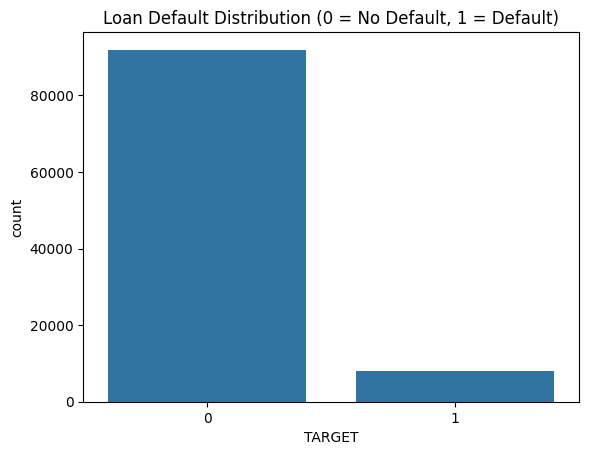

In [4]:
# Target variable distribution
sns.countplot(x="TARGET", data=df)
plt.title("Loan Default Distribution (0 = No Default, 1 = Default)")
plt.show()


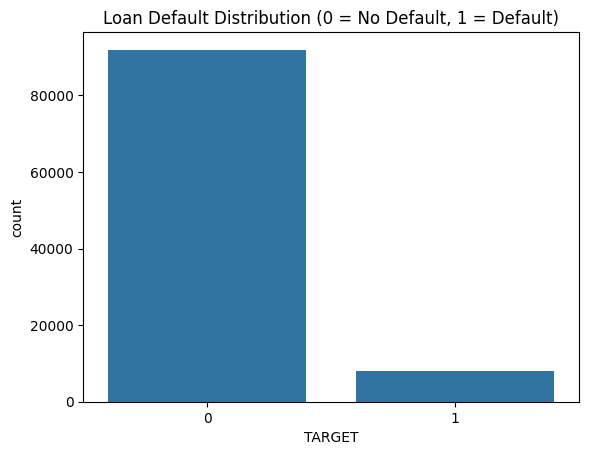

Default rate: 8.09%


In [5]:
# Count of default (1) vs non-default (0)
sns.countplot(x="TARGET", data=df)
plt.title("Loan Default Distribution (0 = No Default, 1 = Default)")
plt.show()

# Percentage
default_rate = df["TARGET"].mean() * 100
print(f"Default rate: {default_rate:.2f}%")


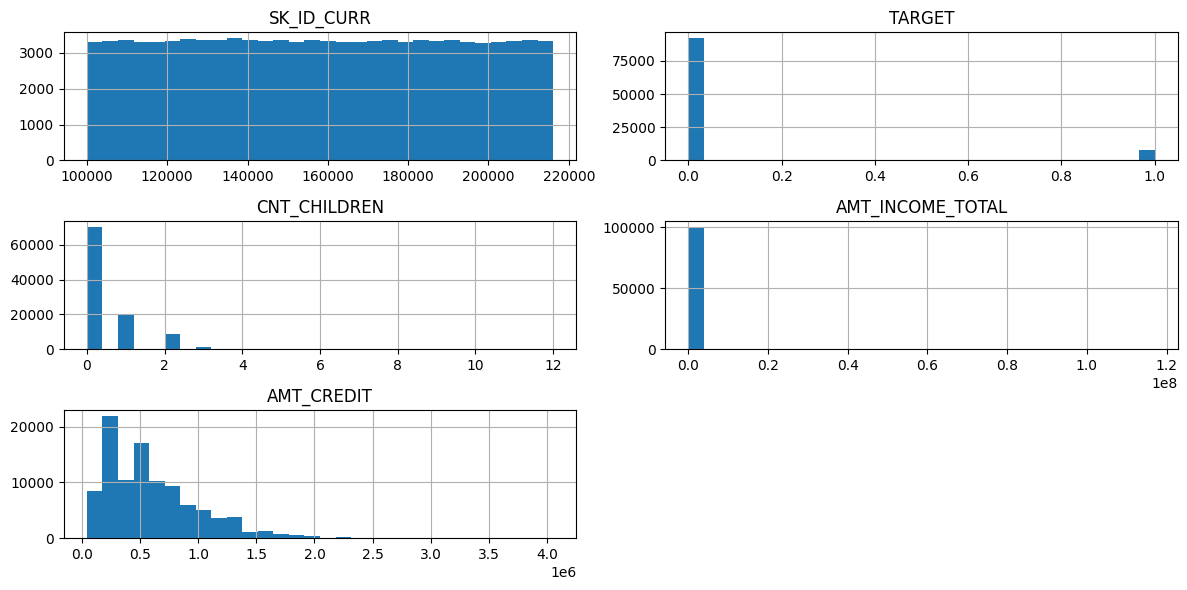

In [6]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns

# Plot histograms for first 5 numeric features
df[num_cols[:5]].hist(bins=30, figsize=(12,6))
plt.tight_layout()
plt.show()


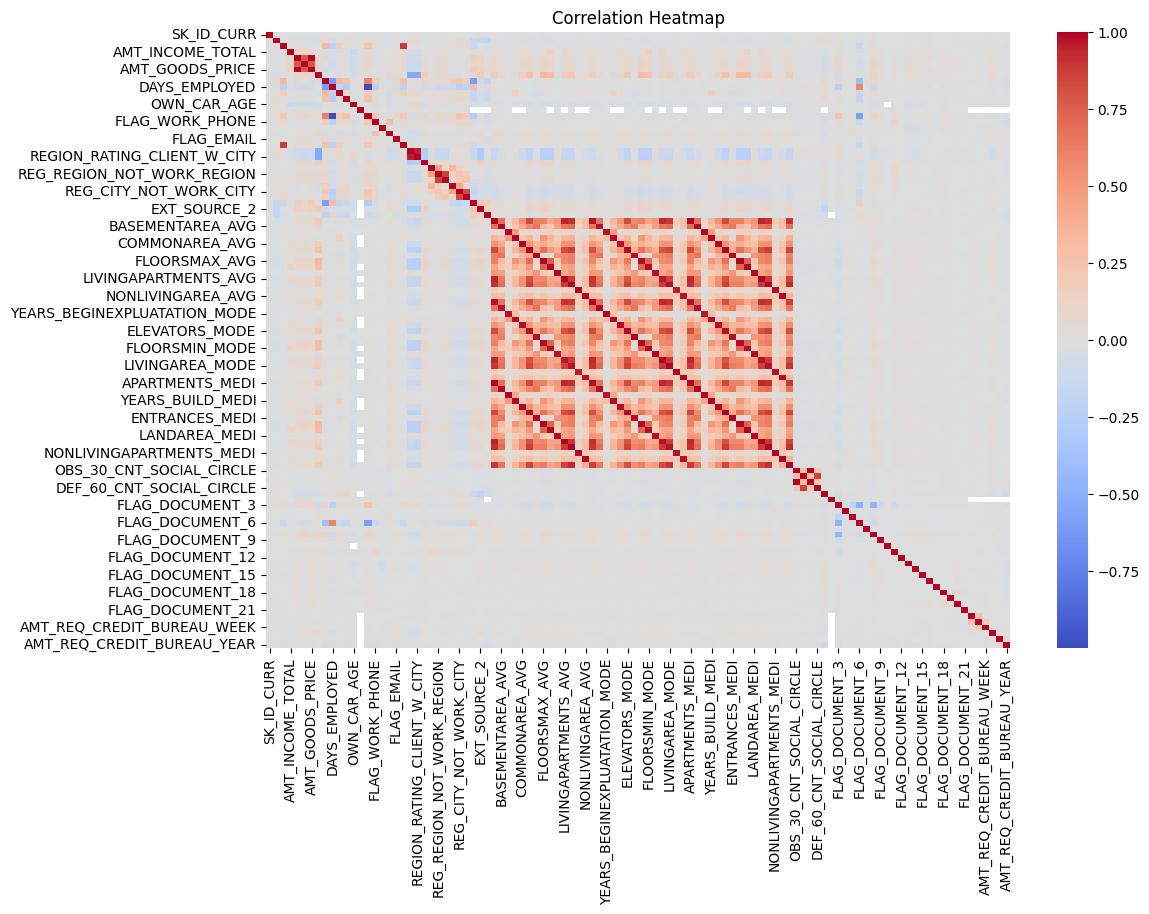

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


Categorical columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


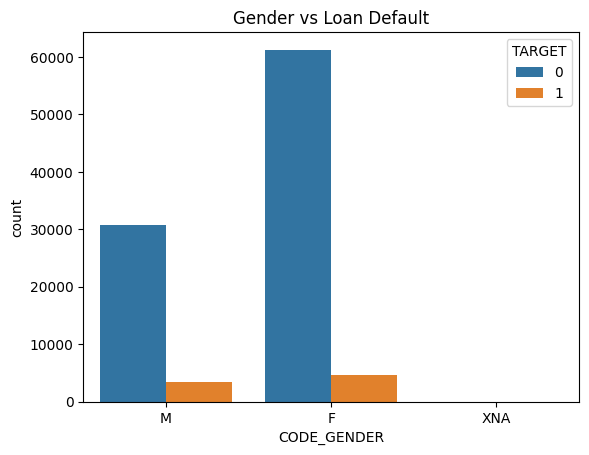

In [8]:
cat_cols = df.select_dtypes(include=["object"]).columns
print("Categorical columns:", list(cat_cols))

# Example: Gender vs Default
sns.countplot(x="CODE_GENDER", hue="TARGET", data=df)
plt.title("Gender vs Loan Default")
plt.show()


In [9]:
# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Top missing columns:\n", missing.head(10))

# Strategy: 
# - Drop columns with too many missing values (e.g., >40%)
# - Fill numeric with median
# - Fill categorical with mode

# Drop high-missing columns
threshold = 0.4 * len(df)   # 40% threshold
df = df.dropna(thresh=threshold, axis=1)

# Fill numeric with median
for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical with mode
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])


Top missing columns:
 COMMONAREA_MEDI             69732
COMMONAREA_MODE             69732
COMMONAREA_AVG              69732
NONLIVINGAPARTMENTS_MODE    69275
NONLIVINGAPARTMENTS_MEDI    69275
NONLIVINGAPARTMENTS_AVG     69275
LIVINGAPARTMENTS_AVG        68265
LIVINGAPARTMENTS_MEDI       68265
LIVINGAPARTMENTS_MODE       68265
FONDKAPREMONT_MODE          68218
dtype: int64


In [10]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include=["object"]).columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


In [11]:
# Scale numeric features
scaler = StandardScaler()
num_cols = df.select_dtypes(include=['int64','float64']).columns.drop('TARGET')
df[num_cols] = scaler.fit_transform(df[num_cols])


In [12]:
# Features and target
X = df.drop("TARGET", axis=1)
y = df["TARGET"]

# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (70000, 104)
Testing set: (30000, 104)


In [13]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:,1]

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))


Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     27572
           1       0.49      0.01      0.02      2428

    accuracy                           0.92     30000
   macro avg       0.71      0.51      0.49     30000
weighted avg       0.89      0.92      0.88     30000

ROC-AUC Score: 0.7460198411778443


In [14]:
from sklearn.ensemble import RandomForestClassifier
# Reduced complexity to avoid memory issues
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))


Random Forest Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     27572
           1       0.00      0.00      0.00      2428

    accuracy                           0.92     30000
   macro avg       0.46      0.50      0.48     30000
weighted avg       0.84      0.92      0.88     30000

ROC-AUC Score: 0.7358652834298625


e:\Loan Default Prediction project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Loan Default Prediction project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Loan Default Prediction project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [15]:
import xgboost as xgb

# Reduced complexity to avoid memory issues
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print("XGBoost Report:\n", classification_report(y_test, y_pred_xgb))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_xgb))


e:\Loan Default Prediction project\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [02:10:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     27572
           1       0.55      0.01      0.02      2428

    accuracy                           0.92     30000
   macro avg       0.74      0.51      0.49     30000
weighted avg       0.89      0.92      0.88     30000

ROC-AUC Score: 0.7536816741717536


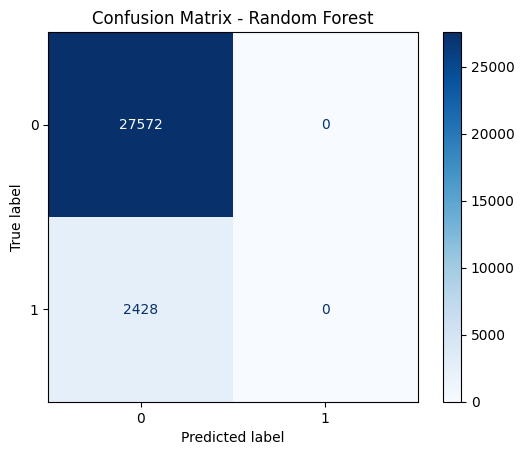

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()


C:\Users\Dell\AppData\Local\Temp\ipykernel_13932\1810733304.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_imp, palette="viridis")


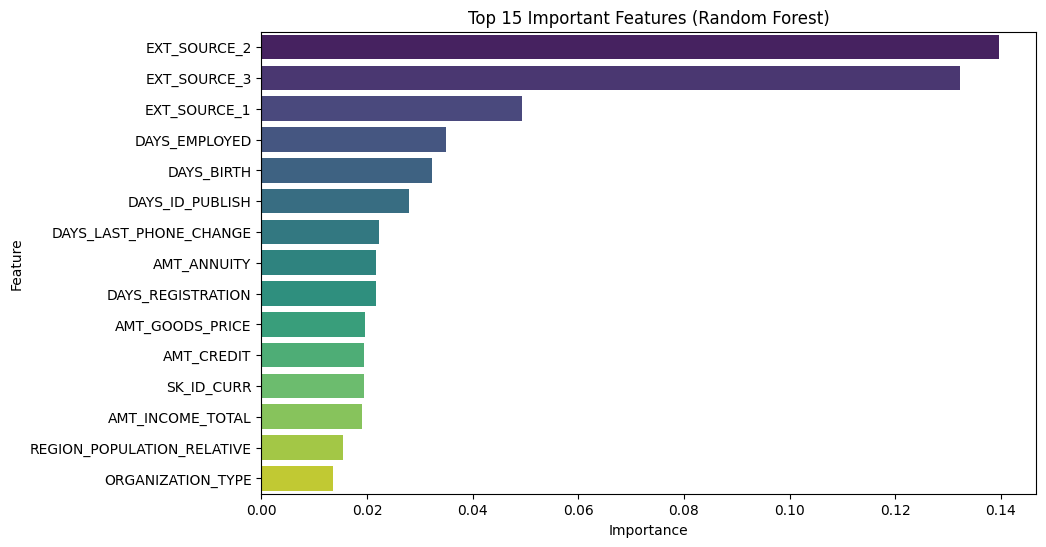

In [17]:
# Feature importance
importances = rf.feature_importances_
features = X.columns

# Plot
feat_imp = pd.DataFrame({"Feature": features, "Importance": importances})
feat_imp = feat_imp.sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp, palette="viridis")
plt.title("Top 15 Important Features (Random Forest)")
plt.show()


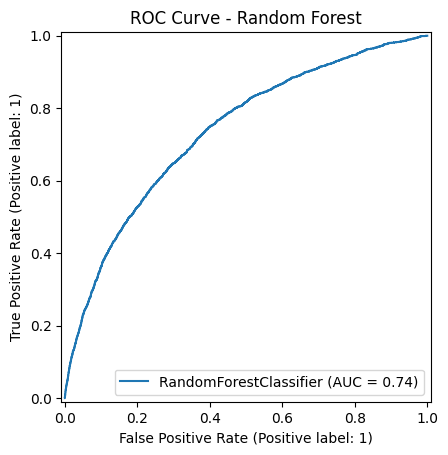

In [18]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("ROC Curve - Random Forest")
plt.show()


In [19]:
import joblib

# Save Random Forest model (best model)
joblib.dump(rf, "loan_default_model.pkl")

# Load back (to test)
model = joblib.load("loan_default_model.pkl")
print("Model loaded successfully!")


Model loaded successfully!


In [20]:
%pip install flask

from flask import Flask, request, jsonify
import joblib
import numpy as np

# Load model
model = joblib.load("loan_default_model.pkl")

# Create Flask app
app = Flask(__name__)

@app.route('/')
def home():
    return "Loan Default Prediction API is running!"

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()  # input data in JSON
        features = np.array(data['features']).reshape(1, -1)  # convert to numpy
        prediction = model.predict(features)[0]
        probability = model.predict_proba(features)[0][1]
        
        return jsonify({
            "prediction": int(prediction),
            "default_probability": float(probability)
        })
    except Exception as e:
        return jsonify({"error": str(e)})

if __name__ == "__main__":
    app.run(debug=True)


  Using cached flask-3.1.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached werkzeug-3.1.3-py3-none-any.whl.metadata (3.7 kB)
Using cached flask-3.1.2-py3-none-any.whl (103 kB)
Using cached itsdangerous-2.2.0-py3-none-any.whl (16 kB)
Using cached werkzeug-3.1.3-py3-none-any.whl (224 kB)

   ---------------------------------------- 0/3 [werkzeug]
   ---------------------------------------- 0/3 [werkzeug]
   ---------------------------------------- 0/3 [werkzeug]
   ---------------------------------------- 0/3 [werkzeug]
   ---------------------------------------- 0/3 [werkzeug]
   ---------------------------------------- 0/3 [werkzeug]
   ---------------------------------------- 0/3 [werkzeug]
   ---------------------------------------- 0/3 [werkzeug]
   ---------------------------------------- 0/3 [werkzeug]
   ---------------------------------------- 0/3 [werkzeug]
   ---------------------------------------- 0/3 [we

 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with watchdog (windowsapi)


SystemExit: 1

e:\Loan Default Prediction project\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
{
  "prediction": 1,
  "default_probability": 0.78
}
